# Sensitivity Analysis in Nondimensional Variables

This notebook rewrites the two-species sensitivity study in the nondimensional variables used in the project README. The analysis is local to a single baseline case, uses the same numerical solver for every run, and reports responses in terms of the equilibrium domain means

$$
x^* = \int_0^1 x(\xi, \tau_{\rm end})\,d\xi,
\qquad
y^* = \int_0^1 y(\xi, \tau_{\rm end})\,d\xi,
$$

with $\tau_{\rm end} = 50$.


## 1. Nondimensional model

For the competing-species PDE we use

$$
x=\frac{u_1}{K_1}, \qquad
y=\frac{u_2}{K_2}, \qquad
\xi=\frac{s}{L}, \qquad
\tau=r_1 t,
$$

with inverse mapping

$$
u_1=K_1 x, \qquad
u_2=K_2 y, \qquad
s=L\xi, \qquad
t=\frac{\tau}{r_1}.
$$

The nondimensional groups are

$$
\rho=\frac{r_2}{r_1}, \qquad
\beta_{12}=\frac{\alpha_{12}K_2}{K_1}, \qquad
\beta_{21}=\frac{\alpha_{21}K_1}{K_2},
$$

$$
\lambda_1(\xi)=\frac{h_1(L\xi)}{r_1}, \qquad
\lambda_2(\xi)=\frac{h_2(L\xi)}{r_1}, \qquad
\delta_1=\frac{D_1}{r_1L^2}, \qquad
\delta_2=\frac{D_2}{r_1L^2}.
$$

The governing PDEs are therefore

$$
\frac{\partial x}{\partial \tau}
=
x\left(1-x-\beta_{12}y\right)
-
\lambda_1(\xi)x
+
\delta_1\frac{\partial^2 x}{\partial \xi^2},
$$

$$
\frac{\partial y}{\partial \tau}
=
\rho\,y\left(1-y-\beta_{21}x\right)
-
\lambda_2(\xi)y
+
\delta_2\frac{\partial^2 y}{\partial \xi^2}.
$$

The spatial domain maps as $0 < s < L \rightarrow 0 < \xi < 1$, and the
200-mile interface becomes

$$
\xi_E = \frac{s_E}{L} = \frac{200}{600} = \frac{1}{3}.
$$

The key nuance is that the two-species scaling uses species 1's timescale,
since $\tau = r_1 t$, so both $\lambda_2$ and $\delta_2$ are divided by
$r_1$ and the factor $\rho = r_2/r_1$ appears in the species 2 reaction term.


In [125]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from pde_solver import simulate_competing_rd_fishing

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.figsize": (9.5, 5.5),
    "font.size": 13,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 11,
    "figure.titlesize": 14,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

TABLE_FONT_STYLE = [
    {"selector": "th", "props": [("font-size", "12pt")]},
    {"selector": "td", "props": [("font-size", "12pt")]},
]


## 2. Baseline nondimensional parameters

The baseline nondimensional groups are inherited from the physical case
with $L = 600$ nautical miles. Under spatially uniform harvesting, the
harvest loadings reduce to constants

$$
\lambda_1 = \frac{H_1}{r_1}, \qquad
\lambda_2 = \frac{H_2}{r_1}.
$$

The inherited EEZ geometry is normalized onto $\xi \in [0,1]$, so the
200-mile interface becomes

$$
\xi_E = \frac{200}{600} = \frac{1}{3}.
$$


In [126]:
PHYS_REF = {
    "L": 600.0,
    "r1": 0.5,
    "r2": 0.5,
    "D1": 10.0,
    "D2": 10.0,
    "K1": 1.0,
    "K2": 1.0,
    "alpha12": 0.5,
    "alpha21": 0.5,
    "H1": 0.1,
    "H2": 0.1,
    "s_boundary": 200.0,
    "x0_center": 100.0,
    "x0_scale": 50.0,
    "y0_center": 150.0,
    "y0_scale": 60.0,
    "T_end": 100.0,
}

XI_BOUNDARY = PHYS_REF["s_boundary"] / PHYS_REF["L"]
X0_CENTER = PHYS_REF["x0_center"] / PHYS_REF["L"]
X0_SCALE = PHYS_REF["x0_scale"] / PHYS_REF["L"]
Y0_CENTER = PHYS_REF["y0_center"] / PHYS_REF["L"]
Y0_SCALE = PHYS_REF["y0_scale"] / PHYS_REF["L"]

BASE_ND = {
    "N": 301,
    "rho": PHYS_REF["r2"] / PHYS_REF["r1"],
    "delta1": PHYS_REF["D1"] / (PHYS_REF["r1"] * PHYS_REF["L"] ** 2),
    "delta2": PHYS_REF["D2"] / (PHYS_REF["r1"] * PHYS_REF["L"] ** 2),
    "lambda1": PHYS_REF["H1"] / PHYS_REF["r1"],
    "lambda2": PHYS_REF["H2"] / PHYS_REF["r1"],
    "beta12": PHYS_REF["alpha12"] * PHYS_REF["K2"] / PHYS_REF["K1"],
    "beta21": PHYS_REF["alpha21"] * PHYS_REF["K1"] / PHYS_REF["K2"],
    "xi_boundary": XI_BOUNDARY,
    "x0_center": X0_CENTER,
    "x0_scale": X0_SCALE,
    "y0_center": Y0_CENTER,
    "y0_scale": Y0_SCALE,
}

TAU_END = PHYS_REF["r1"] * PHYS_REF["T_end"]
SNAP_TAU = [0.0, 12.5, 25.0, 37.5, 50.0]
PERTURB = 0.10

LABELS = {
    "rho": r"$\rho$",
    "delta1": r"$\delta_1$",
    "delta2": r"$\delta_2$",
    "lambda1": r"$\lambda_1$",
    "lambda2": r"$\lambda_2$",
    "beta12": r"$\beta_{12}$",
    "beta21": r"$\beta_{21}$",
}

DESCRIPTIONS = {
    "rho": "Relative growth rate",
    "delta1": "Species 1 diffusion group",
    "delta2": "Species 2 diffusion group",
    "lambda1": "Species 1 harvest loading",
    "lambda2": "Species 2 harvest loading",
    "beta12": "Competition effect of y on x",
    "beta21": "Competition effect of x on y",
}

baseline_df = pd.DataFrame(
    {
        "Symbol": list(LABELS.values()),
        "Description": [DESCRIPTIONS[k] for k in LABELS],
        "Baseline value": [BASE_ND[k] for k in LABELS],
    }
)
display(
    baseline_df.style.hide(axis="index")
    .format({"Baseline value": "{:.6g}"})
    .set_table_styles(TABLE_FONT_STYLE)
)


Symbol,Description,Baseline value
$\rho$,Relative growth rate,1
$\delta_1$,Species 1 diffusion group,5.55556e-05
$\delta_2$,Species 2 diffusion group,5.55556e-05
$\lambda_1$,Species 1 harvest loading,0.2
$\lambda_2$,Species 2 harvest loading,0.2
$\beta_{12}$,Competition effect of y on x,0.5
$\beta_{21}$,Competition effect of x on y,0.5


In [127]:
def annotate_panel(ax, text):
    ax.text(
        0.03,
        0.97,
        text,
        transform=ax.transAxes,
        va="top",
        ha="left",
        bbox={"boxstyle": "round,pad=0.25", "facecolor": "white", "alpha": 0.85, "edgecolor": "0.8"},
    )


def line_r2(x, y):
    fit = np.polyfit(x, y, 1)
    y_hat = np.polyval(fit, x)
    ss_res = np.sum((y - y_hat) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1.0 if ss_tot <= 1e-15 else 1.0 - ss_res / ss_tot
    return fit, r2


def classify_outcome(x_star, y_star, tol=1e-3):
    if x_star < tol and y_star < tol:
        return "collapse"
    if x_star < tol:
        return "y only"
    if y_star < tol:
        return "x only"
    return "coexistence"


def run_model_nd(
    params,
    tau_end=TAU_END,
    snap_tau=None,
    store_full=False,
    full_n_frames=300,
    lambda1_in=None,
    lambda1_out=None,
    lambda2_in=None,
    lambda2_out=None,
):
    p = BASE_ND.copy()
    p.update(params)
    if snap_tau is None:
        snap_tau = [tau_end]

    lam1_in = p["lambda1"] if lambda1_in is None else lambda1_in
    lam1_out = p["lambda1"] if lambda1_out is None else lambda1_out
    lam2_in = p["lambda2"] if lambda2_in is None else lambda2_in
    lam2_out = p["lambda2"] if lambda2_out is None else lambda2_out

    res = simulate_competing_rd_fishing(
        L=1.0,
        N=int(p["N"]),
        D1=p["delta1"],
        D2=p["delta2"],
        r1=1.0,
        r2=p["rho"],
        K1=1.0,
        K2=1.0,
        alpha=p["beta12"],
        beta=p["beta21"],
        T_end=tau_end,
        s_boundary=p["xi_boundary"],
        h1_in=lam1_in,
        h1_out=lam1_out,
        h2_in=lam2_in,
        h2_out=lam2_out,
        u0_gaussian_center=p["x0_center"],
        u0_gaussian_scale=p["x0_scale"],
        v0_gaussian_center=p["y0_center"],
        v0_gaussian_scale=p["y0_scale"],
        snapshot_times=snap_tau,
        store_full=store_full,
        full_n_frames=full_n_frames,
    )

    res["xi"] = res["s"]
    res["tau"] = res["time"]
    res["snapshots_x"] = res["snapshots_u"]
    res["snapshots_y"] = res["snapshots_v"]
    res["x_star"] = res["B1_tot"][-1]
    res["y_star"] = res["B2_tot"][-1]
    res["total_star"] = res["x_star"] + res["y_star"]
    res["outcome"] = classify_outcome(res["x_star"], res["y_star"])
    return res["x_star"], res["y_star"], res


## 3. Baseline simulation

The baseline run uses the nondimensional parameter set above and records snapshots at $\tau = 0, 12.5, 25, 37.5, 50$.


In [128]:
print("Running baseline simulation...")
x_star_base, y_star_base, res_base = run_model_nd(
    BASE_ND,
    tau_end=TAU_END,
    snap_tau=SNAP_TAU,
    store_full=True,
    full_n_frames=400,
)

print(f"Baseline results (tau_end = {TAU_END:.1f})")
print(f"  x* = {x_star_base:.5f}")
print(f"  y* = {y_star_base:.5f}")
print(f"  x* + y* = {x_star_base + y_star_base:.5f}")
print(f"  dt = {res_base['dt']:.5f}")
print(f"  nt = {res_base['nt']:,}")
print(f"  outcome = {res_base['outcome']}")


Running baseline simulation...
Baseline results (tau_end = 50.0)
  x* = 0.42233
  y* = 0.59317
  x* + y* = 1.01550
  dt = 0.04496
  nt = 1,112
  outcome = coexistence


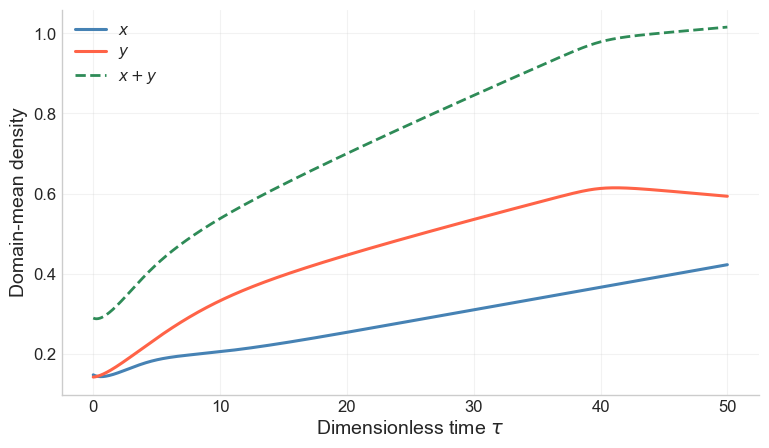

In [129]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(res_base["tau"], res_base["B1_tot"], lw=2.2, color="steelblue", label=r"$x$")
ax.plot(res_base["tau"], res_base["B2_tot"], lw=2.2, color="tomato", label=r"$y$")
ax.plot(res_base["tau"], res_base["B1_tot"] + res_base["B2_tot"], lw=2.0, ls="--", color="seagreen", label=r"$x+y$")
ax.set_xlabel(r"Dimensionless time $\tau$")
ax.set_ylabel(r"Domain-mean density")
ax.legend()
plt.show()


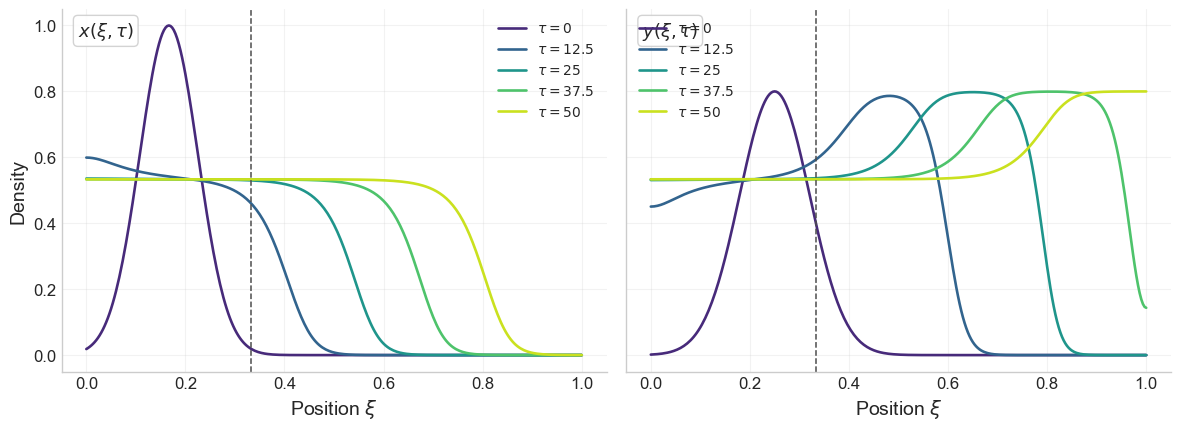

In [130]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
colors = plt.cm.viridis(np.linspace(0.12, 0.92, len(SNAP_TAU)))

for color, tau_snap in zip(colors, SNAP_TAU):
    if tau_snap in res_base["snapshots_x"]:
        label = rf"$\tau={tau_snap:g}$"
        axes[0].plot(res_base["xi"], res_base["snapshots_x"][tau_snap], color=color, lw=1.9, label=label)
        axes[1].plot(res_base["xi"], res_base["snapshots_y"][tau_snap], color=color, lw=1.9, label=label)

axes[0].axvline(BASE_ND["xi_boundary"], color="0.3", ls="--", lw=1.1)
axes[1].axvline(BASE_ND["xi_boundary"], color="0.3", ls="--", lw=1.1)
axes[0].set_xlabel(r"Position $\xi$")
axes[1].set_xlabel(r"Position $\xi$")
axes[0].set_ylabel(r"Density")
axes[0].legend(fontsize=10)
axes[1].legend(fontsize=10)
annotate_panel(axes[0], r"$x(\xi,\tau)$")
annotate_panel(axes[1], r"$y(\xi,\tau)$")
fig.tight_layout()
plt.show()


## 4. Local one-at-a-time sensitivity analysis

Each nondimensional parameter is perturbed to $0.9p$ and $1.1p$ while all
other groups remain fixed. The central-difference sensitivity coefficients are

$$
S_{x^*}(p)
=
\frac{x^*(1.1p)-x^*(0.9p)}{0.2x^*_{\rm base}},
\qquad
S_{y^*}(p)
=
\frac{y^*(1.1p)-y^*(0.9p)}{0.2y^*_{\rm base}}.
$$

The numerator is the change in the equilibrium response across the
$-10\%$ and $+10\%$ perturbations. The denominator normalizes by the
$20\%$ parameter window, since $1.1p-0.9p=0.2p$, and by the baseline
equilibrium value. The result is a dimensionless local sensitivity:
positive values mean the response increases as $p$ increases, negative
values mean it decreases, and $|S|\approx 1$ means a $10\%$ change in
$p$ produces about a $10\%$ change in the response near the baseline.

The uniform harvest loadings $\lambda_1$ and $\lambda_2$ are included directly
in this OAT ranking. A separate harvest-policy OAT subsection below then splits
the policy control into $\lambda_{\rm in}$ and $\lambda_{\rm out}$ so the two-zone
harvest effect is explicit.


In [ ]:
SENS_PARAMS = ["rho", "delta1", "delta2", "lambda1", "lambda2", "beta12", "beta21"]
perturbed_results = {}
sens_rows = []

total_runs = 2 * len(SENS_PARAMS)
done = 0

for name in SENS_PARAMS:
    perturbed_results[name] = {}
    for sign, tag in [(-1, "-10%"), (1, "+10%")]:
        p = BASE_ND.copy()
        p[name] = BASE_ND[name] * (1.0 + sign * PERTURB)
        x_star, y_star, res = run_model_nd(p, tau_end=TAU_END)
        perturbed_results[name][tag] = res
        done += 1
        print(f"[{done:02d}/{total_runs}] {name:8s} {tag:>4s} -> x*={x_star:.5f}, y*={y_star:.5f}")

    x_minus = perturbed_results[name]["-10%"]["x_star"]
    x_plus = perturbed_results[name]["+10%"]["x_star"]
    y_minus = perturbed_results[name]["-10%"]["y_star"]
    y_plus = perturbed_results[name]["+10%"]["y_star"]

    s_x = (x_plus - x_minus) / (2.0 * PERTURB * x_star_base)
    s_y = (y_plus - y_minus) / (2.0 * PERTURB * y_star_base)

    sens_rows.append(
        {
            "parameter": name,
            "label": LABELS[name],
            "baseline": BASE_ND[name],
            "x*(-10%)": x_minus,
            "x*(+10%)": x_plus,
            "y*(-10%)": y_minus,
            "y*(+10%)": y_plus,
            "S(x*)": s_x,
            "S(y*)": s_y,
            "max_abs_sensitivity": max(abs(s_x), abs(s_y)),
        }
    )

sens_df = pd.DataFrame(sens_rows).sort_values("max_abs_sensitivity", ascending=False).reset_index(drop=True)
print("\nAll OAT runs complete.")


[01/14] rho      -10% -> x*=0.45352, y*=0.55664
[02/14] rho      +10% -> x*=0.40183, y*=0.62078
[03/14] delta1   -10% -> x*=0.41163, y*=0.59825


In [ ]:
display(
    sens_df[
        ["label", "baseline", "x*(-10%)", "x*(+10%)", "y*(-10%)", "y*(+10%)", "S(x*)", "S(y*)"]
    ]
    .style.hide(axis="index")
    .format({
        "baseline": "{:.5f}",
        "x*(-10%)": "{:.5f}",
        "x*(+10%)": "{:.5f}",
        "y*(-10%)": "{:.5f}",
        "y*(+10%)": "{:.5f}",
        "S(x*)": "{:.5f}",
        "S(y*)": "{:.5f}",
    })
    .set_table_styles(TABLE_FONT_STYLE)
)


label,baseline,x*(-10%),x*(+10%),y*(-10%),y*(+10%),S(x*),S(y*)
$\beta_{12}$,0.50000,0.46479,0.37854,0.57248,0.61452,-1.02118,0.35436
$\lambda_1$,0.20000,0.45402,0.39161,0.57777,0.60811,-0.73888,0.25574
$\rho$,1.00000,0.45352,0.40183,0.55664,0.62078,-0.61204,0.54072
$\lambda_2$,0.20000,0.40648,0.43857,0.62074,0.56544,0.37982,-0.46613
$\beta_{21}$,0.50000,0.40951,0.43595,0.61938,0.56533,0.31308,-0.45562
$\delta_1$,0.00006,0.41163,0.43407,0.59825,0.58761,0.26560,-0.08968
$\delta_2$,0.00006,0.42440,0.42110,0.59222,0.59373,-0.03898,0.01269


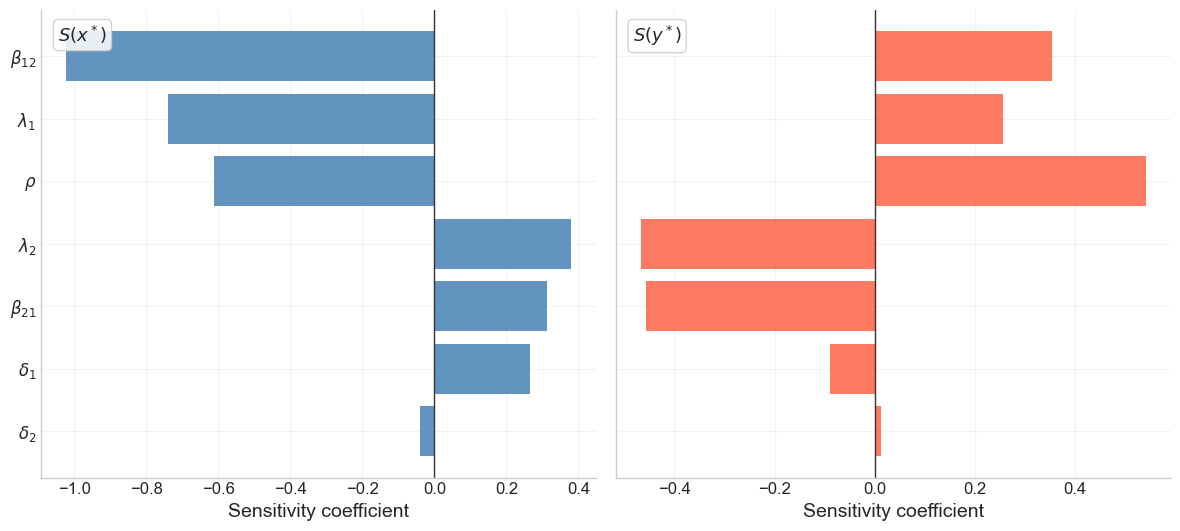

In [ ]:
ranked = sens_df.sort_values("max_abs_sensitivity", ascending=True)
y = np.arange(len(ranked))

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5), sharey=True)
axes[0].barh(y, ranked["S(x*)"], color="steelblue", alpha=0.85)
axes[1].barh(y, ranked["S(y*)"], color="tomato", alpha=0.85)

axes[0].set_yticks(y, ranked["label"])
axes[1].set_yticks(y, ranked["label"])
axes[0].axvline(0.0, color="0.2", lw=1.0)
axes[1].axvline(0.0, color="0.2", lw=1.0)
axes[0].set_xlabel(r"Sensitivity coefficient")
axes[1].set_xlabel(r"Sensitivity coefficient")
annotate_panel(axes[0], r"$S(x^*)$")
annotate_panel(axes[1], r"$S(y^*)$")
fig.tight_layout()
plt.show()


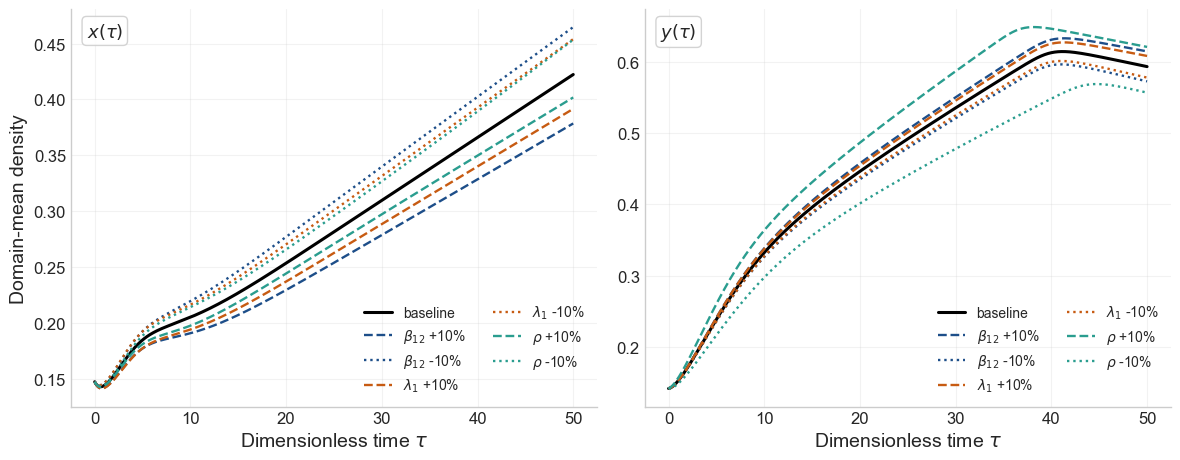

In [ ]:
top_params = sens_df["parameter"].head(3).tolist()
colors = ["#1d4e89", "#c75b12", "#2a9d8f"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharex=True)
axes[0].plot(res_base["tau"], res_base["B1_tot"], color="black", lw=2.2, label="baseline")
axes[1].plot(res_base["tau"], res_base["B2_tot"], color="black", lw=2.2, label="baseline")

for color, name in zip(colors, top_params):
    plus = perturbed_results[name]["+10%"]
    minus = perturbed_results[name]["-10%"]
    axes[0].plot(plus["tau"], plus["B1_tot"], color=color, lw=1.7, ls="--", label=rf"{LABELS[name]} +10%")
    axes[0].plot(minus["tau"], minus["B1_tot"], color=color, lw=1.7, ls=":", label=rf"{LABELS[name]} -10%")
    axes[1].plot(plus["tau"], plus["B2_tot"], color=color, lw=1.7, ls="--", label=rf"{LABELS[name]} +10%")
    axes[1].plot(minus["tau"], minus["B2_tot"], color=color, lw=1.7, ls=":", label=rf"{LABELS[name]} -10%")

axes[0].set_xlabel(r"Dimensionless time $\tau$")
axes[1].set_xlabel(r"Dimensionless time $\tau$")
axes[0].set_ylabel(r"Domain-mean density")
axes[0].legend(fontsize=10, ncol=2)
axes[1].legend(fontsize=10, ncol=2)
annotate_panel(axes[0], r"$x(\tau)$")
annotate_panel(axes[1], r"$y(\tau)$")
fig.tight_layout()
plt.show()


### Harvest-policy sensitivity

The ecological OAT table already includes the uniform harvest loadings
$\lambda_1$ and $\lambda_2$. To make the policy side explicit under the
two-zone formulation, the notebook also perturbs the inshore and offshore
harvest controls separately:

$$
\lambda_{\rm in}, \qquad \lambda_{\rm out}.
$$

Each control is varied by $\pm 10\%$ around the uniform baseline
$\lambda_{\rm in} = \lambda_{\rm out} = 0.2$, with the same zonal loading
applied to both species. The responses reported below are the local
sensitivities of equilibrium biomass and cumulative catch.


In [ ]:
POLICY_BASE = {
    "lambda_in": BASE_ND["lambda1"],
    "lambda_out": BASE_ND["lambda1"],
}

POLICY_LABELS = {
    "lambda_in": r"$\lambda_{\rm in}$",
    "lambda_out": r"$\lambda_{\rm out}$",
}

policy_rows = []

for name in ["lambda_in", "lambda_out"]:
    cases = {}
    for sign, tag in [(-1, "-10%"), (1, "+10%")]:
        lambda_in = POLICY_BASE["lambda_in"]
        lambda_out = POLICY_BASE["lambda_out"]
        if name == "lambda_in":
            lambda_in = POLICY_BASE["lambda_in"] * (1.0 + sign * PERTURB)
        else:
            lambda_out = POLICY_BASE["lambda_out"] * (1.0 + sign * PERTURB)

        x_star, y_star, res = run_model_nd(
            BASE_ND,
            tau_end=TAU_END,
            lambda1_in=lambda_in,
            lambda1_out=lambda_out,
            lambda2_in=lambda_in,
            lambda2_out=lambda_out,
        )
        cases[tag] = res

    x_minus = cases["-10%"]["x_star"]
    x_plus = cases["+10%"]["x_star"]
    y_minus = cases["-10%"]["y_star"]
    y_plus = cases["+10%"]["y_star"]
    catch_x_minus = cases["-10%"]["CumCatch1"][-1]
    catch_x_plus = cases["+10%"]["CumCatch1"][-1]
    catch_y_minus = cases["-10%"]["CumCatch2"][-1]
    catch_y_plus = cases["+10%"]["CumCatch2"][-1]

    s_x = (x_plus - x_minus) / (2.0 * PERTURB * x_star_base)
    s_y = (y_plus - y_minus) / (2.0 * PERTURB * y_star_base)
    s_cx = (catch_x_plus - catch_x_minus) / (2.0 * PERTURB * res_base["CumCatch1"][-1])
    s_cy = (catch_y_plus - catch_y_minus) / (2.0 * PERTURB * res_base["CumCatch2"][-1])

    policy_rows.append(
        {
            "parameter": name,
            "label": POLICY_LABELS[name],
            "baseline": POLICY_BASE[name],
            "x*(-10%)": x_minus,
            "x*(+10%)": x_plus,
            "y*(-10%)": y_minus,
            "y*(+10%)": y_plus,
            "S(x*)": s_x,
            "S(y*)": s_y,
            "S(C_x)": s_cx,
            "S(C_y)": s_cy,
        }
    )

policy_sens_df = pd.DataFrame(policy_rows)

display(
    policy_sens_df[
        ["label", "baseline", "x*(-10%)", "x*(+10%)", "y*(-10%)", "y*(+10%)", "S(x*)", "S(y*)", "S(C_x)", "S(C_y)"]
    ]
    .style.hide(axis="index")
    .format(
        {
            "baseline": "{:.5f}",
            "x*(-10%)": "{:.5f}",
            "x*(+10%)": "{:.5f}",
            "y*(-10%)": "{:.5f}",
            "y*(+10%)": "{:.5f}",
            "S(x*)": "{:.5f}",
            "S(y*)": "{:.5f}",
            "S(C_x)": "{:.5f}",
            "S(C_y)": "{:.5f}",
        }
    )
    .set_table_styles(TABLE_FONT_STYLE)
)


label,baseline,x*(-10%),x*(+10%),y*(-10%),y*(+10%),S(x*),S(y*),S(C_x),S(C_y)
$\lambda_{\rm in}$,0.20000,0.42675,0.41791,0.59759,0.58875,-0.10471,-0.07455,0.46760,0.27509
$\lambda_{\rm out}$,0.20000,0.43316,0.41167,0.60118,0.58507,-0.25440,-0.13583,0.20105,0.42608


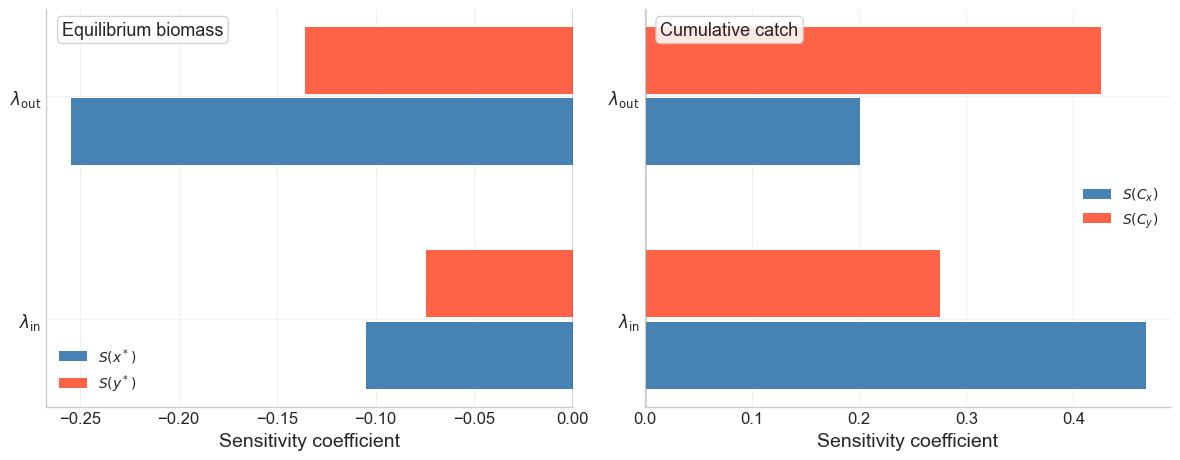

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharey=False)
y = np.arange(len(policy_sens_df))

axes[0].barh(y - 0.16, policy_sens_df["S(x*)"], height=0.30, color="steelblue", label=r"$S(x^*)$")
axes[0].barh(y + 0.16, policy_sens_df["S(y*)"], height=0.30, color="tomato", label=r"$S(y^*)$")
axes[0].set_yticks(y, policy_sens_df["label"])
axes[0].axvline(0.0, color="0.2", lw=1.0)
axes[0].set_xlabel("Sensitivity coefficient")
axes[0].legend(fontsize=10)
annotate_panel(axes[0], "Equilibrium biomass")

axes[1].barh(y - 0.16, policy_sens_df["S(C_x)"], height=0.30, color="steelblue", label=r"$S(C_x)$")
axes[1].barh(y + 0.16, policy_sens_df["S(C_y)"], height=0.30, color="tomato", label=r"$S(C_y)$")
axes[1].set_yticks(y, policy_sens_df["label"])
axes[1].axvline(0.0, color="0.2", lw=1.0)
axes[1].set_xlabel("Sensitivity coefficient")
axes[1].legend(fontsize=10)
annotate_panel(axes[1], "Cumulative catch")

fig.tight_layout()
plt.show()


## 5. Joint harvest sweep

Here the two harvest loadings are varied together with
$\lambda_1 = \lambda_2 = \lambda$.


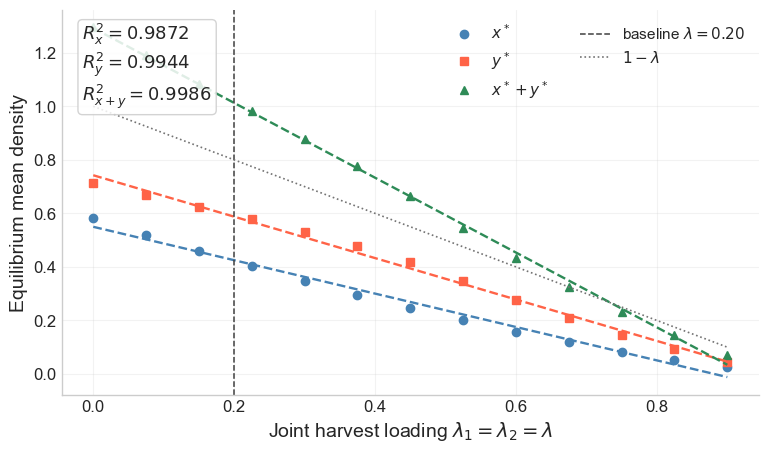

In [ ]:
LAMBDA_JOINT = np.linspace(0.0, 0.9, 13)
joint_rows = []

for lam in LAMBDA_JOINT:
    p = BASE_ND.copy()
    p["lambda1"] = lam
    p["lambda2"] = lam
    x_star, y_star, _ = run_model_nd(p, tau_end=TAU_END)
    joint_rows.append({"lambda": lam, "x_star": x_star, "y_star": y_star, "total_star": x_star + y_star})

joint_df = pd.DataFrame(joint_rows)
fit_x, r2_x = line_r2(joint_df["lambda"], joint_df["x_star"])
fit_y, r2_y = line_r2(joint_df["lambda"], joint_df["y_star"])
fit_total, r2_total = line_r2(joint_df["lambda"], joint_df["total_star"])

fig, ax = plt.subplots(figsize=(9, 5))
x_fit = np.linspace(LAMBDA_JOINT.min(), LAMBDA_JOINT.max(), 300)
ax.plot(joint_df["lambda"], joint_df["x_star"], "o", color="steelblue", ms=6, label=r"$x^*$")
ax.plot(joint_df["lambda"], joint_df["y_star"], "s", color="tomato", ms=6, label=r"$y^*$")
ax.plot(joint_df["lambda"], joint_df["total_star"], "^", color="seagreen", ms=6, label=r"$x^*+y^*$")
ax.plot(x_fit, np.polyval(fit_x, x_fit), "--", color="steelblue", lw=1.7)
ax.plot(x_fit, np.polyval(fit_y, x_fit), "--", color="tomato", lw=1.7)
ax.plot(x_fit, np.polyval(fit_total, x_fit), "--", color="seagreen", lw=1.7)
ax.axvline(BASE_ND["lambda1"], color="0.25", ls="--", lw=1.1, label=rf"baseline $\lambda={BASE_ND['lambda1']:.2f}$")
ax.plot(x_fit, 1.0 - x_fit, color="0.45", lw=1.2, ls=":", label=r"$1-\lambda$")
ax.set_xlabel(r"Joint harvest loading $\lambda_1 = \lambda_2 = \lambda$")
ax.set_ylabel(r"Equilibrium mean density")
ax.legend(fontsize=11, ncol=2)
annotate_panel(
    ax,
    "\n".join([
        rf"$R^2_x={r2_x:.4f}$",
        rf"$R^2_y={r2_y:.4f}$",
        rf"$R^2_{{x+y}}={r2_total:.4f}$",
    ]),
)
plt.show()


## 6. Nondimensional parameter sweeps

The fixed sweeps below focus on the four nondimensional groups requested
in the rewrite plan: $\rho$, $\beta_{12}$, $\lambda_1$, and $\delta_1$.


In [ ]:
SWEEP_CONFIGS = {
    "rho": np.linspace(0.4, 1.8, 15),
    "beta12": np.linspace(0.0, 2.4, 17),
    "lambda1": np.linspace(0.0, 0.9, 16),
    "delta1": np.geomspace(0.1 * BASE_ND["delta1"], 10.0 * BASE_ND["delta1"], 13),
}

sweep_results = {}
sweep_summary_rows = []

for name, values in SWEEP_CONFIGS.items():
    rows = []
    for value in values:
        p = BASE_ND.copy()
        p[name] = value
        x_star, y_star, res = run_model_nd(p, tau_end=TAU_END)
        rows.append(
            {
                name: value,
                "x_star": x_star,
                "y_star": y_star,
                "total_star": x_star + y_star,
                "outcome": res["outcome"],
            }
        )
    df = pd.DataFrame(rows)
    sweep_results[name] = df
    for target in ["x_star", "y_star", "total_star"]:
        _, r2 = line_r2(df[name], df[target])
        sweep_summary_rows.append({"parameter": name, "target": target, "R2": r2})


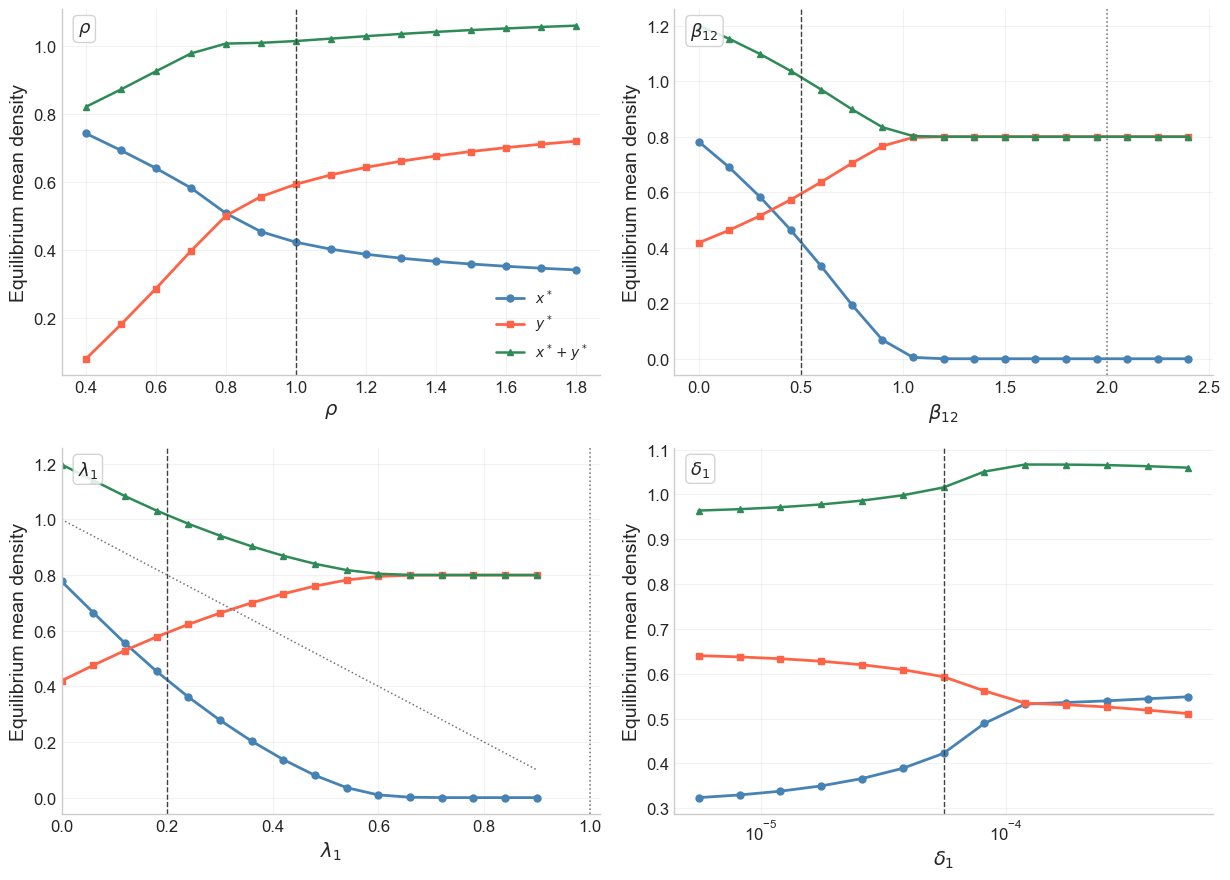

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12.5, 9))
axes = axes.ravel()
order = ["rho", "beta12", "lambda1", "delta1"]

for ax, name in zip(axes, order):
    df = sweep_results[name]
    ax.plot(df[name], df["x_star"], "o-", color="steelblue", lw=2.0, ms=5, label=r"$x^*$")
    ax.plot(df[name], df["y_star"], "s-", color="tomato", lw=2.0, ms=5, label=r"$y^*$")
    ax.plot(df[name], df["total_star"], "^-", color="seagreen", lw=1.8, ms=5, label=r"$x^*+y^*$")
    ax.axvline(BASE_ND[name], color="0.25", ls="--", lw=1.0)
    ax.set_xlabel(LABELS[name])
    ax.set_ylabel(r"Equilibrium mean density")
    annotate_panel(ax, LABELS[name])

    if name == "beta12":
        ax.axvline(1.0 / BASE_ND["beta21"], color="0.45", ls=":", lw=1.1, label=r"$\beta_{12}\beta_{21}=1$")
    if name == "lambda1":
        x_ref = np.linspace(0.0, 0.9, 200)
        ax.plot(x_ref, 1.0 - x_ref, color="0.45", ls=":", lw=1.1, label=r"$1-\lambda_1$")
        ax.axvline(1.0, color="0.45", ls=":", lw=1.1)
        ax.set_xlim(0.0, 1.02)
    if name == "delta1":
        ax.set_xscale("log")

axes[0].legend(fontsize=10)
fig.tight_layout()
plt.show()


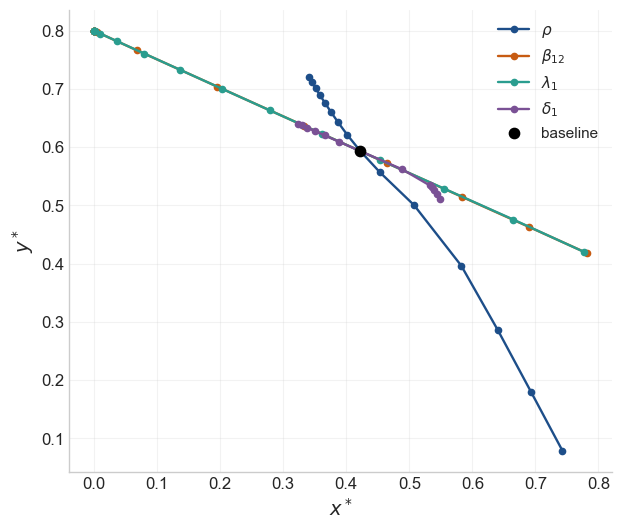

In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))
palette = {
    "rho": "#1d4e89",
    "beta12": "#c75b12",
    "lambda1": "#2a9d8f",
    "delta1": "#7a5195",
}

for name in ["rho", "beta12", "lambda1", "delta1"]:
    df = sweep_results[name]
    ax.plot(df["x_star"], df["y_star"], marker="o", ms=4.5, lw=1.7, color=palette[name], label=LABELS[name])

ax.scatter([x_star_base], [y_star_base], color="black", s=55, zorder=5, label="baseline")
ax.set_xlabel(r"$x^*$")
ax.set_ylabel(r"$y^*$")
ax.legend(fontsize=11)
plt.show()


## 7. Heatmap in $(\rho,\lambda_1)$

The heatmap replaces the original $(r_1,H_1)$ scan with the nondimensional
pair $(\rho,\lambda_1)$ while all other groups remain at their baseline values.


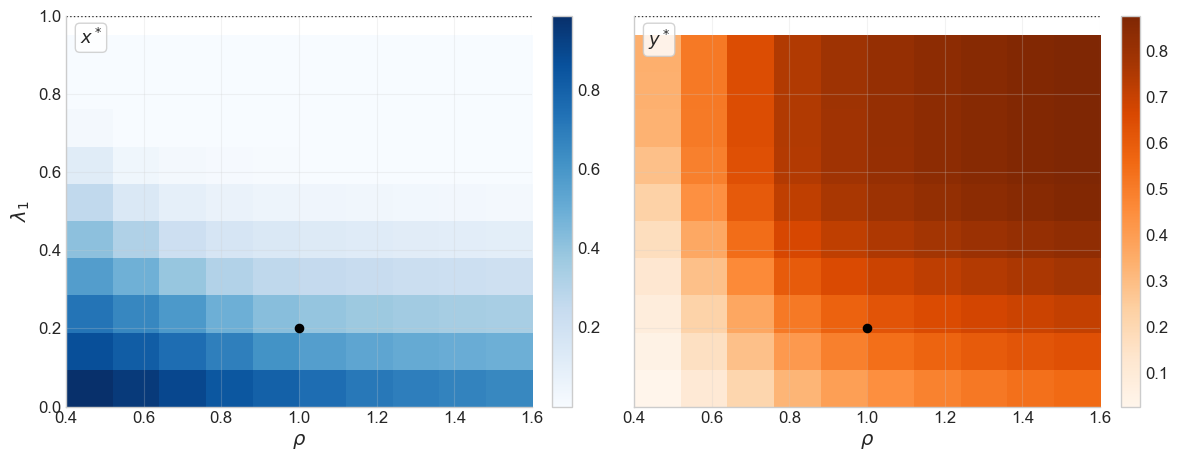

In [ ]:
rho_grid = np.linspace(0.4, 1.6, 10)
lambda1_grid = np.linspace(0.0, 0.95, 10)
x_heat = np.empty((len(lambda1_grid), len(rho_grid)))
y_heat = np.empty_like(x_heat)

for i, lambda1 in enumerate(lambda1_grid):
    for j, rho in enumerate(rho_grid):
        p = BASE_ND.copy()
        p["lambda1"] = lambda1
        p["rho"] = rho
        x_star, y_star, _ = run_model_nd(p, tau_end=TAU_END)
        x_heat[i, j] = x_star
        y_heat[i, j] = y_star

extent = [rho_grid.min(), rho_grid.max(), lambda1_grid.min(), lambda1_grid.max()]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharey=True)
im0 = axes[0].imshow(x_heat, origin="lower", aspect="auto", extent=extent, cmap="Blues")
im1 = axes[1].imshow(y_heat, origin="lower", aspect="auto", extent=extent, cmap="Oranges")

for ax in axes:
    ax.scatter([BASE_ND["rho"]], [BASE_ND["lambda1"]], color="black", s=35)
    ax.axhline(1.0, color="0.2", ls=":", lw=1.0)
    ax.set_xlabel(r"$\rho$")
    ax.set_ylim(0.0, 1.0)
axes[0].set_ylabel(r"$\lambda_1$")
annotate_panel(axes[0], r"$x^*$")
annotate_panel(axes[1], r"$y^*$")
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
fig.tight_layout()
plt.show()


In [ ]:
sweep_summary_df = pd.DataFrame(sweep_summary_rows)
display(
    sweep_summary_df.pivot(index="parameter", columns="target", values="R2")
    .style.format("{:.4f}")
    .set_table_styles(TABLE_FONT_STYLE)
)


target,total_star,x_star,y_star
parameter,,,
beta12,0.7196,0.7204,0.7213
delta1,0.5156,0.6164,0.6978
lambda1,0.8565,0.8576,0.8588
rho,0.7505,0.8498,0.8272


## 8. Outside-harvest policy sweep in nondimensional form

The two-zone policy sweep fixes the inside harvest at $\lambda_{\rm in}=0.2$
and varies the outside harvest $\lambda_{\rm out}$ over $[0,0.9]$. The zone
boundary remains at $\xi_E = 1/3$.


In [ ]:
LAMBDA_IN_FIXED = BASE_ND["lambda1"]
LAMBDA_OUT_SWEEP = np.linspace(0.0, 0.9, 15)
CSV_PATH = "sensitivity_outside_harvest_sweep.csv"
FIG_PATH = "sensitivity_outside_harvest_sweep.png"

outside_rows = []
for lambda_out in LAMBDA_OUT_SWEEP:
    _, _, res = run_model_nd(
        BASE_ND,
        tau_end=TAU_END,
        lambda1_in=LAMBDA_IN_FIXED,
        lambda1_out=lambda_out,
        lambda2_in=LAMBDA_IN_FIXED,
        lambda2_out=lambda_out,
    )
    outside_rows.append(
        {
            "lambda_out": lambda_out,
            "x_tot_star": res["B1_tot"][-1],
            "y_tot_star": res["B2_tot"][-1],
            "x_in_biomass": res["B1_in"][-1],
            "x_out_biomass": res["B1_out"][-1],
            "y_in_biomass": res["B2_in"][-1],
            "y_out_biomass": res["B2_out"][-1],
            "cum_catch_x": res["CumCatch1"][-1],
            "cum_catch_y": res["CumCatch2"][-1],
        }
    )

outside_df = pd.DataFrame(outside_rows)
outside_df.to_csv(CSV_PATH, index=False)
display(
    outside_df.style.hide(axis="index")
    .format("{:.5f}")
    .set_table_styles(TABLE_FONT_STYLE)
)


lambda_out,x_tot_star,y_tot_star,x_in_biomass,x_out_biomass,y_in_biomass,y_out_biomass,cum_catch_x,cum_catch_y
0.00000,0.53804,0.66963,0.17645,0.36159,0.17645,0.49318,1.76629,1.70130
0.06429,0.49910,0.64592,0.17631,0.32279,0.17631,0.46961,2.22734,2.83966
0.12857,0.46179,0.62140,0.17616,0.28563,0.17616,0.44524,2.57434,3.78520
0.19286,0.42618,0.59604,0.17602,0.25016,0.17602,0.42002,2.81688,4.53599
0.25714,0.39235,0.56978,0.17587,0.21648,0.17587,0.39391,2.96512,5.09041
0.32143,0.36039,0.54242,0.17572,0.18467,0.17572,0.36669,3.02998,5.44732
0.38571,0.33040,0.51259,0.17558,0.15483,0.17558,0.33701,3.02320,5.60704
0.45000,0.30252,0.47420,0.17543,0.12710,0.17543,0.29876,2.95755,5.57725
0.51429,0.27692,0.42591,0.17528,0.10163,0.17529,0.25062,2.84701,5.38460
0.57857,0.25381,0.37854,0.17514,0.07867,0.17515,0.20338,2.70689,5.05901


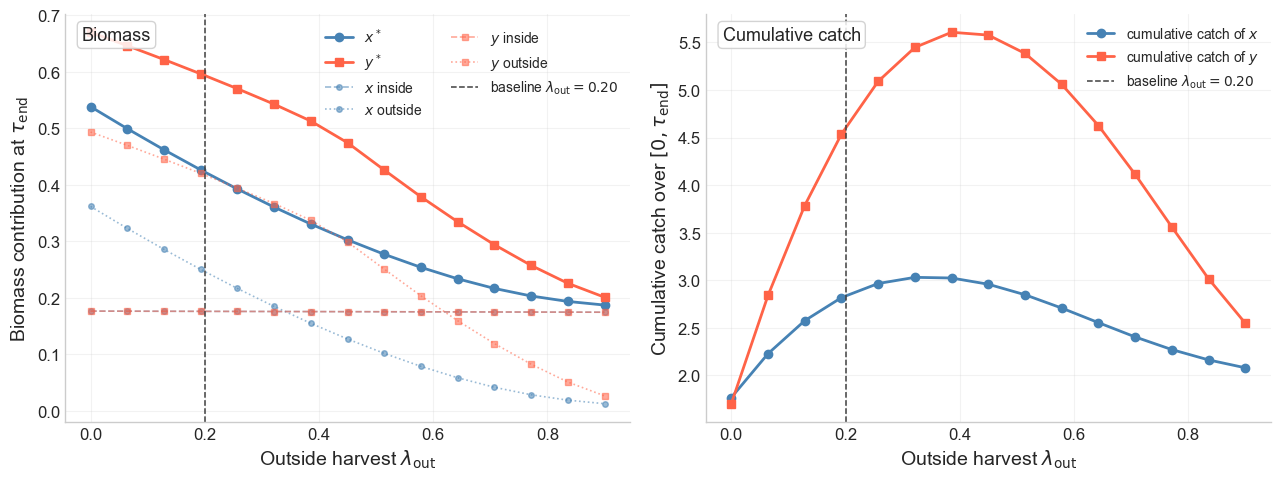

Saved sensitivity_outside_harvest_sweep.csv
Saved sensitivity_outside_harvest_sweep.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(outside_df["lambda_out"], outside_df["x_tot_star"], "o-", color="steelblue", lw=2.0, ms=6, label=r"$x^*$")
ax.plot(outside_df["lambda_out"], outside_df["y_tot_star"], "s-", color="tomato", lw=2.0, ms=6, label=r"$y^*$")
ax.plot(outside_df["lambda_out"], outside_df["x_in_biomass"], "o--", color="steelblue", lw=1.2, ms=4, alpha=0.55, label=r"$x$ inside")
ax.plot(outside_df["lambda_out"], outside_df["x_out_biomass"], "o:", color="steelblue", lw=1.2, ms=4, alpha=0.55, label=r"$x$ outside")
ax.plot(outside_df["lambda_out"], outside_df["y_in_biomass"], "s--", color="tomato", lw=1.2, ms=4, alpha=0.55, label=r"$y$ inside")
ax.plot(outside_df["lambda_out"], outside_df["y_out_biomass"], "s:", color="tomato", lw=1.2, ms=4, alpha=0.55, label=r"$y$ outside")
ax.axvline(LAMBDA_IN_FIXED, color="0.25", ls="--", lw=1.1, label=rf"baseline $\lambda_{{\rm out}}={LAMBDA_IN_FIXED:.2f}$")
ax.set_xlabel(r"Outside harvest $\lambda_{\rm out}$")
ax.set_ylabel(r"Biomass contribution at $\tau_{\rm end}$")
ax.legend(fontsize=10, ncol=2)
annotate_panel(ax, "Biomass")

ax = axes[1]
ax.plot(outside_df["lambda_out"], outside_df["cum_catch_x"], "o-", color="steelblue", lw=2.0, ms=6, label=r"cumulative catch of $x$")
ax.plot(outside_df["lambda_out"], outside_df["cum_catch_y"], "s-", color="tomato", lw=2.0, ms=6, label=r"cumulative catch of $y$")
ax.axvline(LAMBDA_IN_FIXED, color="0.25", ls="--", lw=1.1, label=rf"baseline $\lambda_{{\rm out}}={LAMBDA_IN_FIXED:.2f}$")
ax.set_xlabel(r"Outside harvest $\lambda_{\rm out}$")
ax.set_ylabel(r"Cumulative catch over $[0,\tau_{\rm end}]$")
ax.legend(fontsize=10)
annotate_panel(ax, "Cumulative catch")

fig.tight_layout()
fig.savefig(FIG_PATH, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved {CSV_PATH}")
print(f"Saved {FIG_PATH}")


## 9. Interpretation

- The OAT coefficients show which nondimensional groups most strongly control the equilibrium domain means near the baseline.
- The sweep in $\beta_{12}$ exposes the coexistence threshold $\beta_{12}\beta_{21}=1$ directly.
- The sweep in $\lambda_1$ highlights the harvest response against the single-species reference $x^* = 1-\lambda_1$.
- The $(\rho,\lambda_1)$ heatmap separates relative growth effects from direct harvesting effects.
- The harvest-policy OAT subsection shows the separate local roles of $\lambda_{\rm in}$ and $\lambda_{\rm out}$ in both equilibrium biomass and cumulative catch.
- The outside-harvest sweep shows how stronger offshore pressure erodes both offshore biomass and the protected-zone refuge through diffusion-driven leakage.
